In [1]:
# Import necessary libraries
from pyspark.sql import SparkSession

# Create a Spark session
spark = SparkSession.builder \
    .appName("YelpUserAnalysis") \
    .getOrCreate()

24/11/21 22:29:28 WARN Utils: Your hostname, yelp resolves to a loopback address: 127.0.1.1; using 192.168.64.2 instead (on interface enp0s1)
24/11/21 22:29:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/11/21 22:29:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
reviews_df = spark.read.json("file:///home/dps/Documents/yelp_dataset/yelp_academic_dataset_review.json")

In [3]:
users_df = spark.read.json("file:///home/dps/Documents/yelp_dataset/yelp_academic_dataset_user.json")

In [4]:
arizona_businesses_df = spark.read.parquet("file:///home/dps/Documents/temp/arizona_businesses.parquet")

24/11/21 22:29:54 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [5]:
# Filter for businesses in the chosen category (e.g., Restaurants)
category_reviews_df = reviews_df.join(arizona_businesses_df, reviews_df.business_id == arizona_businesses_df.business_id) \
                                .filter(arizona_businesses_df["categories"].contains("Restaurants"))

category_reviews_df.show(5)


+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+----------+---------------+--------------------+-----------+------------+-----+-----+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|             address|          attributes|         business_id|          categories|  city|               hours|is_open|  latitude|      longitude|                name|postal_code|review_count|stars|state|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+----------+---------------+--------------------+-----------+------------+-----+--

In [6]:
# Join reviews with user data
user_reviews_df = category_reviews_df.join(users_df, category_reviews_df.user_id == users_df.user_id)

# Display the first few rows
user_reviews_df.show(5)


+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+------------+---------------+--------------------+-----------+------------+-----+-----+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+----+--------------------+----+--------------------+-----+-----+------------+------+--------------------+-------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|             address|          attributes|         business_id|          categories|  city|               hours|is_open|    latitude|      longitude|                name|postal_code|review_count|stars|state|aver

In [7]:
# Alias the DataFrames to avoid ambiguity
reviews_df = reviews_df.alias("reviews")
users_df = users_df.alias("users")

# Join reviews with user data, specifying the columns explicitly to avoid ambiguity
user_reviews_df = reviews_df.join(users_df, reviews_df["user_id"] == users_df["user_id"], "inner") \
    .select(reviews_df["user_id"], users_df["name"], reviews_df["text"], reviews_df["business_id"], users_df["review_count"])

# Show the first few rows to verify
user_reviews_df.show(5)

+--------------------+----+--------------------+--------------------+------------+
|             user_id|name|                text|         business_id|review_count|
+--------------------+----+--------------------+--------------------+------------+
|--6lqYpHZCBbpW5z2...|Jeff|Honestly was only...|mUI4DJagyUyu76qnR...|           9|
|--Kwhcbkh7jxkhVVQ...|Larz|The place is abso...|ORL4JE6tz3rJxVqkd...|          58|
|--Kwhcbkh7jxkhVVQ...|Larz|Ate dinner there ...|tIvfmgT1qMeAEQf8C...|          58|
|--Kwhcbkh7jxkhVVQ...|Larz|It was okay. If y...|Ld805G25xHALqbBo1...|          58|
|--Kwhcbkh7jxkhVVQ...|Larz|Went for a nice l...|arQfMJal1tl67Z96R...|          58|
+--------------------+----+--------------------+--------------------+------------+
only showing top 5 rows



In [8]:
# Query 1: Top 5 Users Based on Number of Compliments

from pyspark.sql.functions import col, sum as _sum

compliment_cols = [c for c in users_df.columns if c.startswith('compliment_')]

users_compliments_df = users_df.withColumn("total_compliments", sum([col(c) for c in compliment_cols]))

top_users_compliments_df = users_compliments_df.orderBy(col("total_compliments").desc()).limit(5)

top_users_compliments_df.select("user_id", "name", "total_compliments").show()

+--------------------+-------+-----------------+
|             user_id|   name|total_compliments|
+--------------------+-------+-----------------+
|JjXuiru1_ONzDkYVr...|Richard|           324328|
|Tqm7Wu7IBJ1td3Ab5...|  Brian|           277314|
|ax7SnXOTIpatbsmqH...| Rohlin|           154351|
|--2vR0DIsmQ6WfcSz...| Harald|           133351|
|h4oOQdnfjpEHbygEJ...|   John|           132032|
+--------------------+-------+-----------------+



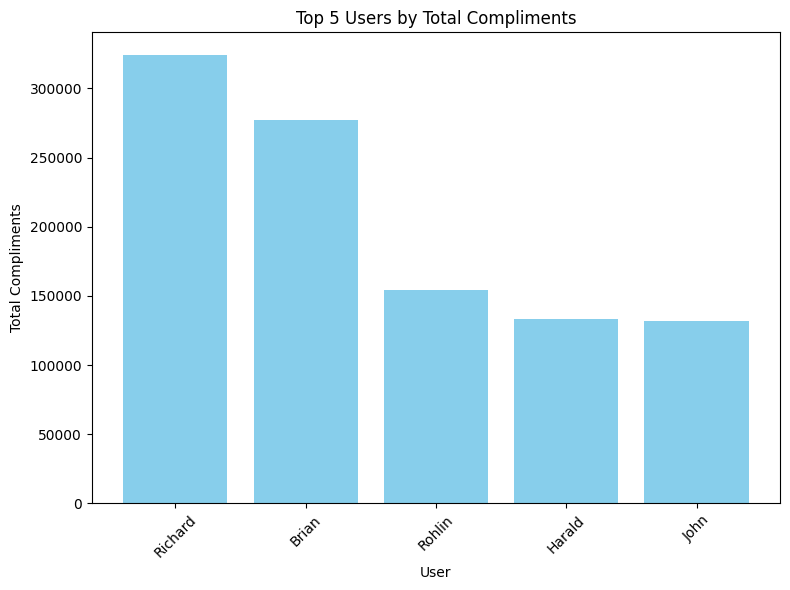

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

top_users_compliments_pd = top_users_compliments_df.select("name", "total_compliments").toPandas()

plt.figure(figsize=(8,6))
plt.bar(top_users_compliments_pd['name'], top_users_compliments_pd['total_compliments'], color='skyblue')
plt.title("Top 5 Users by Total Compliments")
plt.xlabel("User")
plt.ylabel("Total Compliments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Query 2: Top 10 Users by Number of Friends

from pyspark.sql.functions import size, split

users_with_friends_count_df = users_df.withColumn("friends_count", size(split(col("friends"), ",")))

top_users_by_friends_df = users_with_friends_count_df.orderBy(col("friends_count").desc()).limit(10)

top_users_by_friends_df.select("user_id", "name", "friends_count").show()

+--------------------+------+-------------+
|             user_id|  name|friends_count|
+--------------------+------+-------------+
|qVc8ODYU5SZjKXVBg...|Walker|        14995|
|iLjMdZi0Tm7DQxX1C...| Ruggy|        12395|
|ZIOCmdFaMIF56FR-n...| Randy|        11026|
|mV4lknblF-zOKSF8n...| Scott|        10366|
|Oi1qbcz2m2SnwUezt...|Steven|        10072|
|hizGc5W1tBHPghM5Y...| Katie|         9390|
|IU86PZPgTDCFwJEuA...| Danny|         9217|
|n4Y6wdh6om3QtIFlW...|   Rob|         8989|
|djxnI8Ux8ZYQJhiOQ...|  Abby|         8858|
|F_5_UNX-wrAFCXuAk...|Rodney|         8809|
+--------------------+------+-------------+



<Figure size 1200x600 with 0 Axes>

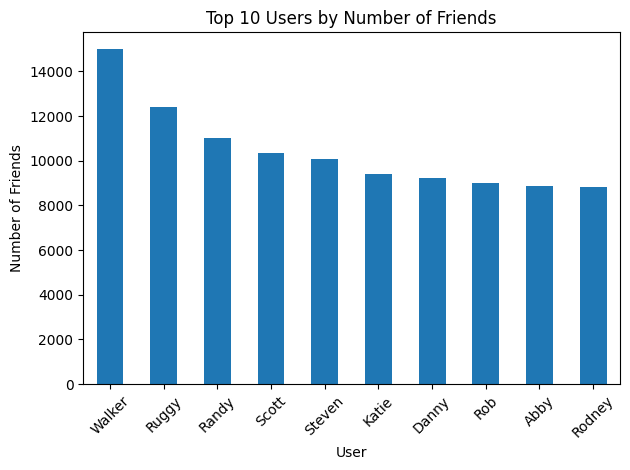

In [11]:
top_users_by_friends_pd = top_users_by_friends_df.select("name", "friends_count").toPandas()

plt.figure(figsize=(12,6))
top_users_by_friends_pd.plot(kind='bar', x='name', y='friends_count', legend=False)
plt.title("Top 10 Users by Number of Friends")
plt.xlabel("User")
plt.ylabel("Number of Friends")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Query 3: Number of Users Joined per Year

from pyspark.sql.functions import year, to_timestamp, col

users_year_df = users_df.withColumn("yelping_year", year(to_timestamp(col("yelping_since"), 'yyyy-MM-dd HH:mm:ss')))

users_per_year_df = users_year_df.groupBy("yelping_year").count().orderBy("yelping_year")

users_per_year_df.show()

+------------+------+
|yelping_year| count|
+------------+------+
|        2004|    90|
|        2005|   937|
|        2006|  5423|
|        2007| 15340|
|        2008| 31097|
|        2009| 64911|
|        2010|109054|
|        2011|176435|
|        2012|195955|
|        2013|209762|
|        2014|233465|
|        2015|247850|
|        2016|217620|
|        2017|151024|
|        2018|133568|
|        2019|104655|
|        2020| 47444|
|        2021| 40485|
|        2022|  2782|
+------------+------+



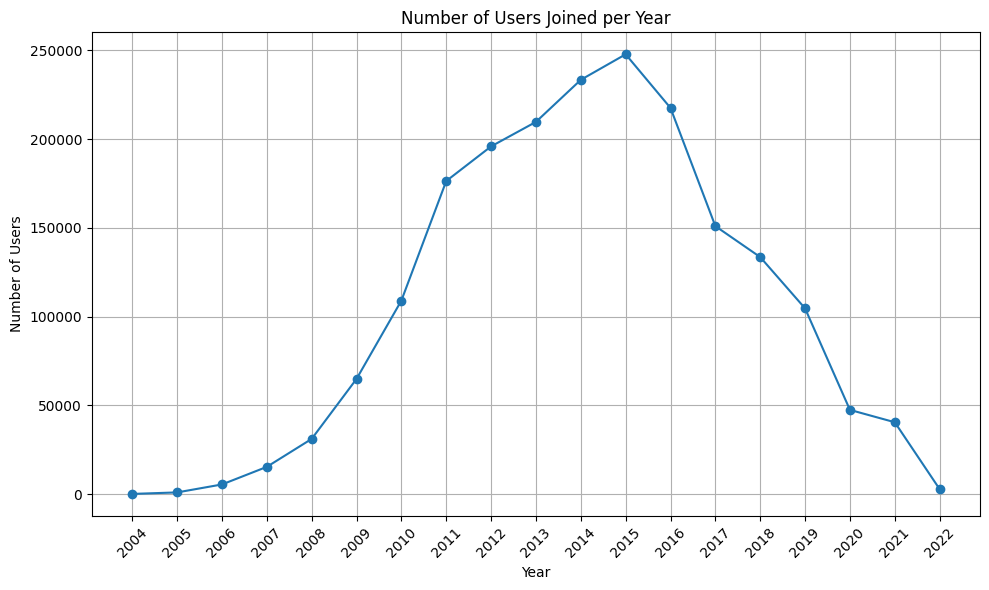

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

users_per_year_pd = users_per_year_df.toPandas()

plt.figure(figsize=(10,6))
plt.plot(users_per_year_pd["yelping_year"], users_per_year_pd["count"], marker='o', linestyle='-')
plt.title("Number of Users Joined per Year")
plt.xlabel("Year")
plt.ylabel("Number of Users")
plt.xticks(users_per_year_pd["yelping_year"], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# Query 4: Correlation Between User's Review Count and Number of Fans

from pyspark.sql.functions import corr

correlation = users_df.stat.corr("review_count", "fans")

print(f"Correlation between review count and number of fans: {correlation}")

Correlation between review count and number of fans: 0.5341902489143021


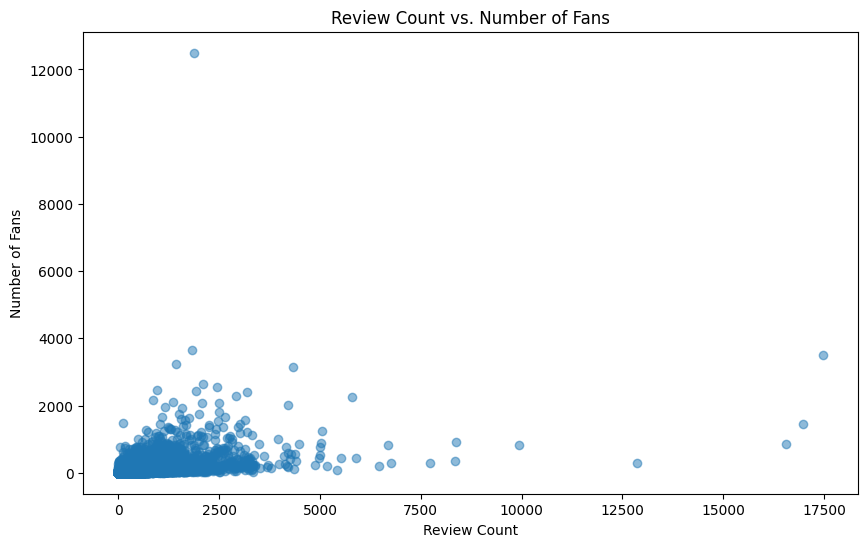

In [15]:
review_fans_pd = users_df.select("review_count", "fans").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(review_fans_pd["review_count"], review_fans_pd["fans"], alpha=0.5)
plt.title("Review Count vs. Number of Fans")
plt.xlabel("Review Count")
plt.ylabel("Number of Fans")
plt.show()

In [16]:
# Query 5: Average Star Rating Given by Users, Varying with User's Elite Status

from pyspark.sql.functions import col, avg

user_reviews_df = reviews_df.join(users_df.select("user_id", "elite"), on="user_id")

arizona_restaurants_df = arizona_businesses_df.filter(col("categories").contains("Restaurants"))
user_reviews_arizona_df = user_reviews_df.join(arizona_restaurants_df.select("business_id"), on="business_id")

user_reviews_arizona_df = user_reviews_arizona_df.withColumn("is_elite", col("elite") != "")

average_stars_df = user_reviews_arizona_df.groupBy("is_elite").agg(avg("stars").alias("average_star_rating"))

average_stars_df.show()

24/11/21 22:31:22 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:22 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:22 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:22 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+--------+-------------------+
|is_elite|average_star_rating|
+--------+-------------------+
|    true| 3.9155992522329157|
|   false| 3.6554853479383427|
+--------+-------------------+



24/11/21 22:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:40 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:31:40 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


<Figure size 800x600 with 0 Axes>

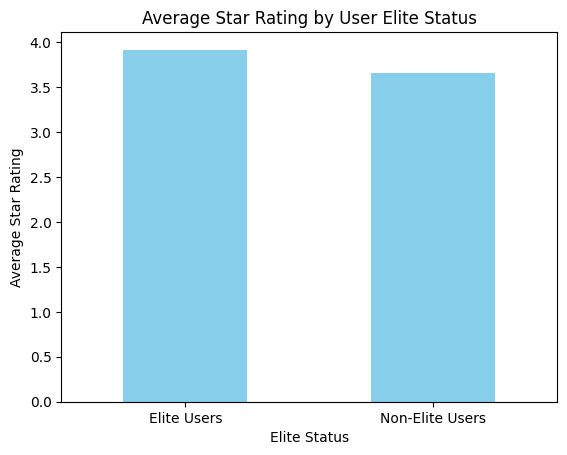

In [17]:
average_stars_pd = average_stars_df.toPandas()

average_stars_pd['is_elite'] = average_stars_pd['is_elite'].map({True: 'Elite Users', False: 'Non-Elite Users'})

plt.figure(figsize=(8,6))
average_stars_pd.plot(kind='bar', x='is_elite', y='average_star_rating', legend=False, color=['skyblue'])
plt.title("Average Star Rating by User Elite Status")
plt.xlabel("Elite Status")
plt.ylabel("Average Star Rating")
plt.xticks(rotation=0)
plt.show()

In [18]:
# Query 6: Compare Average Review Length Between Users with Different Number of Friends

from pyspark.sql.functions import size, split, length, when

users_with_friends_df = users_df.withColumn("friends_count", size(split(col("friends"), ",")))

user_reviews_df = reviews_df.join(users_with_friends_df.select("user_id", "friends_count"), on="user_id")

user_reviews_arizona_df = user_reviews_df.join(arizona_restaurants_df.select("business_id"), on="business_id")

user_reviews_arizona_df = user_reviews_arizona_df.withColumn("review_length", length(col("text")))

user_reviews_arizona_df = user_reviews_arizona_df.withColumn(
    "friends_bin",
    when(col("friends_count") < 10, "<10")
    .when((col("friends_count") >= 10) & (col("friends_count") < 50), "10-49")
    .when((col("friends_count") >= 50) & (col("friends_count") < 100), "50-99")
    .otherwise("100+")
)

average_review_length_df = user_reviews_arizona_df.groupBy("friends_bin").agg(avg("review_length").alias("average_review_length"))

average_review_length_df.show()

+-----------+---------------------+
|friends_bin|average_review_length|
+-----------+---------------------+
|       100+|    645.9207308719775|
|      50-99|    583.4625959374904|
|        <10|     471.157917499694|
|      10-49|    532.9881081081081|
+-----------+---------------------+



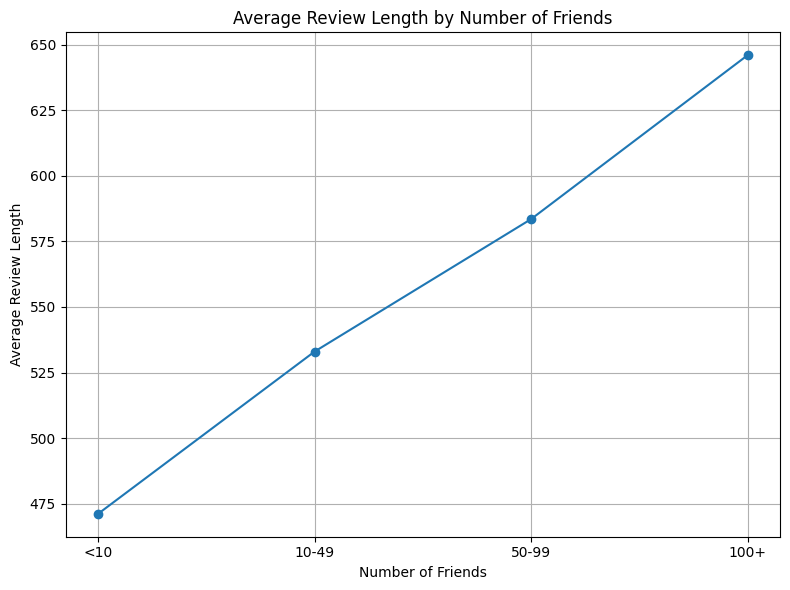

In [19]:
average_review_length_pd = average_review_length_df.toPandas()

bin_order = ["<10", "10-49", "50-99", "100+"]
average_review_length_pd['friends_bin'] = pd.Categorical(average_review_length_pd['friends_bin'], categories=bin_order, ordered=True)
average_review_length_pd = average_review_length_pd.sort_values('friends_bin')

plt.figure(figsize=(8,6))
plt.plot(average_review_length_pd['friends_bin'], average_review_length_pd['average_review_length'], marker='o', linestyle='-')
plt.title("Average Review Length by Number of Friends")
plt.xlabel("Number of Friends")
plt.ylabel("Average Review Length")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Query 7: Relationship Between User's Average Star Rating Given and Average Star Rating of Businesses They Review

from pyspark.sql.functions import avg

user_avg_stars_df = reviews_df.groupBy("user_id").agg(avg("stars").alias("user_avg_stars"))

business_avg_stars_df = arizona_restaurants_df.select("business_id", col("stars").alias("business_avg_stars"))

user_business_df = reviews_df.join(business_avg_stars_df, on="business_id")

user_business_avg_df = user_business_df.groupBy("user_id").agg(avg("business_avg_stars").alias("avg_business_stars"))

user_stars_df = user_avg_stars_df.join(user_business_avg_df, on="user_id")

user_stars_df.show(5)

+--------------------+------------------+------------------+
|             user_id|    user_avg_stars|avg_business_stars|
+--------------------+------------------+------------------+
|--A15Rp8LJspfurcz...|               5.0|3.6666666666666665|
|--CIuK7sUpaNzalLA...|2.4444444444444446|               2.0|
|--_N9jPdYR9WdJKQh...|               2.0|2.8333333333333335|
|--cPqjzKHqHKmGala...| 4.266666666666667|               4.0|
|--gafFJlfUIwzifH5...|               5.0|               4.5|
+--------------------+------------------+------------------+
only showing top 5 rows



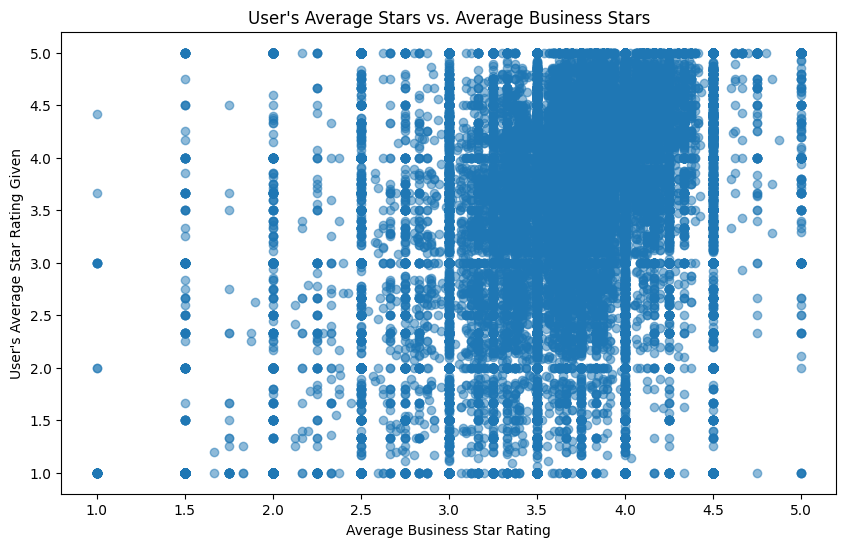

In [21]:
user_stars_pd = user_stars_df.select("user_avg_stars", "avg_business_stars").toPandas()

plt.figure(figsize=(10,6))
plt.scatter(user_stars_pd["avg_business_stars"], user_stars_pd["user_avg_stars"], alpha=0.5)
plt.title("User's Average Stars vs. Average Business Stars")
plt.xlabel("Average Business Star Rating")
plt.ylabel("User's Average Star Rating Given")
plt.show()

In [22]:
# Query 8: Analyze Review Sentiments Across Users with Different Review Counts

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from pyspark.sql.functions import udf, when, avg
from pyspark.sql.types import DoubleType

nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sid.polarity_scores(text)['compound']

sentiment_udf = udf(get_sentiment, DoubleType())

user_reviews_df = reviews_df.join(users_df.select("user_id", "review_count"), on="user_id")

user_reviews_arizona_df = user_reviews_df.join(arizona_restaurants_df.select("business_id"), on="business_id")

user_reviews_arizona_df = user_reviews_arizona_df.withColumn("sentiment_score", sentiment_udf(col("text")))

user_reviews_arizona_df = user_reviews_arizona_df.withColumn(
    "review_count_bin",
    when(col("review_count") < 10, "<10")
    .when((col("review_count") >= 10) & (col("review_count") < 50), "10-49")
    .when((col("review_count") >= 50) & (col("review_count") < 100), "50-99")
    .otherwise("100+")
)

average_sentiment_df = user_reviews_arizona_df.groupBy("review_count_bin").agg(avg("sentiment_score").alias("average_sentiment"))

average_sentiment_df.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/dps/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
24/11/21 22:33:41 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:41 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:41 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:45 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:33:52 WARN RowBasedKey

+----------------+------------------+
|review_count_bin| average_sentiment|
+----------------+------------------+
|            100+|0.7670739795154383|
|           50-99|0.7092309524505365|
|             <10|   0.5296355155391|
|           10-49|0.6463547043734362|
+----------------+------------------+



24/11/21 22:34:56 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:34:56 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:34:56 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:00 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:05 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:07 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/11/21 22:35:08 WARN RowBasedKeyValueBatch: Calling spill() on

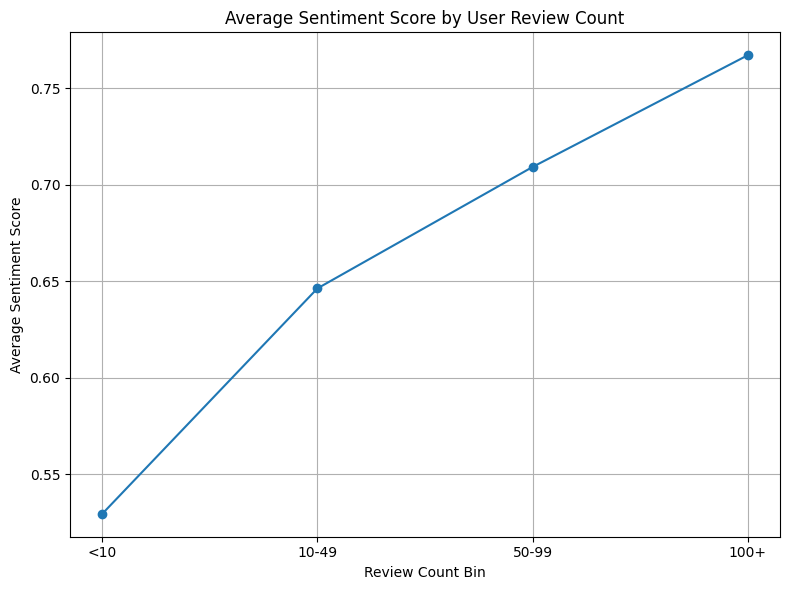

In [23]:
average_sentiment_pd = average_sentiment_df.toPandas()

bin_order = ["<10", "10-49", "50-99", "100+"]
average_sentiment_pd['review_count_bin'] = pd.Categorical(average_sentiment_pd['review_count_bin'], categories=bin_order, ordered=True)
average_sentiment_pd = average_sentiment_pd.sort_values('review_count_bin')

plt.figure(figsize=(8,6))
plt.plot(average_sentiment_pd['review_count_bin'], average_sentiment_pd['average_sentiment'], marker='o', linestyle='-')
plt.title("Average Sentiment Score by User Review Count")
plt.xlabel("Review Count Bin")
plt.ylabel("Average Sentiment Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Query 9: Investigate if Users Who Have More Compliments Write Longer Reviews

from pyspark.sql.functions import expr, when, avg, col, length

compliment_cols = [c for c in users_df.columns if c.startswith('compliment_')]
compliment_sum_expr = " + ".join(compliment_cols)
users_with_compliments_df = users_df.withColumn("total_compliments", expr(compliment_sum_expr))

users_with_compliments_df = users_with_compliments_df.withColumn(
    "compliments_bin",
    when(col("total_compliments") == 0, "0")
    .when((col("total_compliments") >= 1) & (col("total_compliments") <= 5), "1-5")
    .when((col("total_compliments") >= 6) & (col("total_compliments") <= 20), "6-20")
    .otherwise("21+")
)

user_reviews_df = reviews_df.join(users_with_compliments_df.select("user_id", "compliments_bin"), on="user_id")

arizona_restaurants_df = arizona_businesses_df.filter(col("categories").contains("Restaurants"))
user_reviews_arizona_df = user_reviews_df.join(arizona_restaurants_df.select("business_id"), on="business_id")

user_reviews_arizona_df = user_reviews_arizona_df.withColumn("review_length", length(col("text")))

average_length_df = user_reviews_arizona_df.groupBy("compliments_bin").agg(avg("review_length").alias("average_review_length"))

bin_order_desc = ["21+", "6-20", "1-5", "0"]

average_length_pd = average_length_df.toPandas()

average_length_pd['compliments_bin'] = pd.Categorical(average_length_pd['compliments_bin'], categories=bin_order_desc, ordered=True)
average_length_pd = average_length_pd.sort_values('compliments_bin', ascending=False)

print(average_length_pd)

  compliments_bin  average_review_length
0               0             412.681784
3             1-5             482.475791
2            6-20             572.893419
1             21+             760.827784


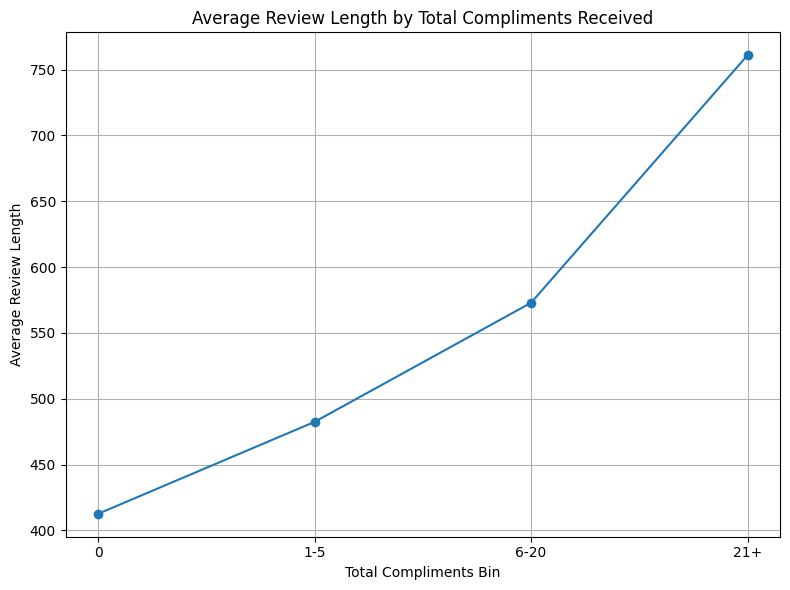

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(average_length_pd['compliments_bin'], average_length_pd['average_review_length'], marker='o', linestyle='-')
plt.title("Average Review Length by Total Compliments Received")
plt.xlabel("Total Compliments Bin")
plt.ylabel("Average Review Length")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Query 10: Analyze User Loyalty by Number of Reviews per Business

from pyspark.sql.functions import col, count as _count

arizona_restaurants_df = arizona_businesses_df.filter(col("categories").contains("Restaurants"))
arizona_reviews_df = reviews_df.join(arizona_restaurants_df.select("business_id"), on="business_id")

user_business_counts_df = arizona_reviews_df.groupBy("user_id", "business_id").count()

loyal_users_df = user_business_counts_df.filter(col("count") > 1)

loyal_users_df.orderBy(col("count").desc()).show(10)

review_counts_df = loyal_users_df.groupBy("count").agg(_count("*").alias("pair_count")).orderBy("count")

review_counts_df.show()

+--------------------+--------------------+-----+
|             user_id|         business_id|count|
+--------------------+--------------------+-----+
|xWmYN57XXZbg0LOK8...|gfLsBY-xsNE9-ktiT...|   31|
|mVtmlFPxA8cBzhaum...|aYHjJJ64whQsxZjx5...|   20|
|mVtmlFPxA8cBzhaum...|k-QEp8E_1cJU3poJS...|   12|
|W9kZgeqUS24aVjpAH...|4QeHIdYwzBIB2HS_M...|   10|
|mVtmlFPxA8cBzhaum...|3F777YJJYthdPNrB-...|   10|
|ma1MsTANyRHA640Kn...|QO4E57PptMqNMrSS9...|    9|
|mVtmlFPxA8cBzhaum...|WZUIlyefoUhuH_VkV...|    9|
|mVtmlFPxA8cBzhaum...|tP8wd-9CrI_RkHK42...|    8|
|4Dy4PVb5lykv4N0kY...|HpmsY3JJ4gIuS8EiV...|    8|
|J9c0XM-wV_KQmtZYx...|5s7I0Khg7ReVzfO7n...|    8|
+--------------------+--------------------+-----+
only showing top 10 rows



+-----+----------+
|count|pair_count|
+-----+----------+
|    2|      8712|
|    3|       923|
|    4|       189|
|    5|        60|
|    6|        21|
|    7|        11|
|    8|         9|
|    9|         2|
|   10|         2|
|   12|         1|
|   20|         1|
|   31|         1|
+-----+----------+



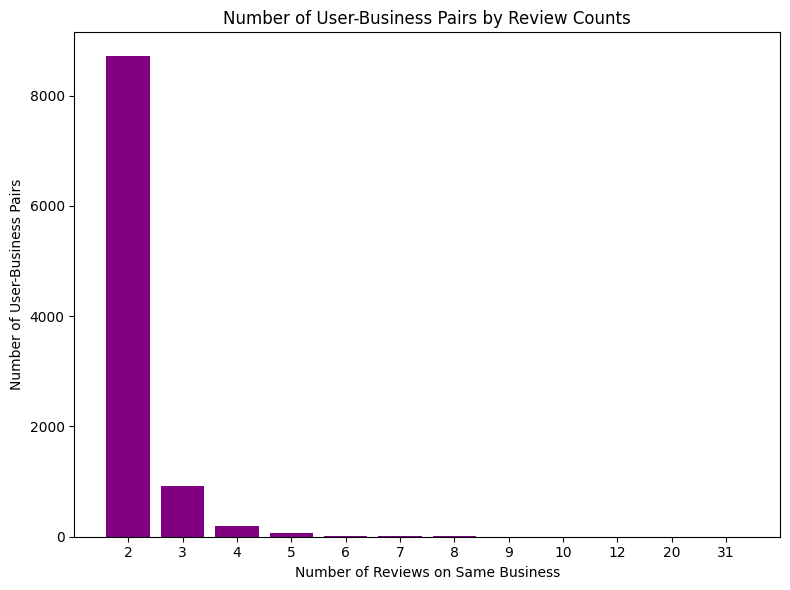

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

review_counts_pd = review_counts_df.toPandas()

plt.figure(figsize=(8,6))
plt.bar(review_counts_pd['count'].astype(str), review_counts_pd['pair_count'], color='purple')
plt.title("Number of User-Business Pairs by Review Counts")
plt.xlabel("Number of Reviews on Same Business")
plt.ylabel("Number of User-Business Pairs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()